In [47]:
from  mobilenetv2.models.imagenet.mbnetv2 import mbnetv2
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math, os
import numpy as np
import cv2

In [48]:
cfgs = [
            [1,  16, 1, 1],
            [6,  24, 2, 2],
            [6,  32, 3, 2],
            [6,  64, 4, 2],
            
            [6,  96, 3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]
cfgs = [cfg[2] for cfg in cfgs]

In [49]:
def convert_state_dict(pretrained_sd,cfgs):
    new_sd = {}
    for k, v in pretrained_sd.items():
        # print(f"Converting {k} to ")
        # print(v)
        # First layer mapping
        if k.startswith('features.0'):
            new_key = k.replace('features.0', 'first_conv')
            new_sd[new_key] = v
        # Bottleneck blocks mapping (may need to adjust for all indices)
        elif k.startswith('features'):
            parts = k.split('.')
            block_idx = int(parts[1]) - 1      # because features.0 is first_conv
            # Find the corresponding config
            idx_1 = 0
            idx_2 = 0
            for i, cfg in enumerate(cfgs):
                if sum(cfgs[:i+1]) > block_idx:
                    idx_1 = i
                    idx_2 = block_idx - sum(cfgs[:i])
                    break

            rest = '.'.join(parts[2:])
            new_key = f'bottleneck_sequential_blocks.{idx_1}.{idx_2}.{rest}'
            new_sd[new_key] = v
        # Last layers mapping (if present)
        elif k.startswith('conv'):
            new_sd[k] = v
        elif k.startswith('classifier'):
            new_sd[k] = v
        else:
            # Handle or ignore unexpected keys
            pass
    return new_sd

In [50]:
pretrained_sd = torch.load('mobilenetv2/pretrained/mobilenetv2-c5e733a8.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
data_dir = 'KITTI_data/'


cuda


/tmp/ipykernel_229979/1263802277.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_sd = torch.load('mobilenetv2/pretrained/mobilenetv2-c5e733a8.pth')


## Prepare KITTI Data
Before proceeding we need to prepare the depth dataset from the depth disparity data provided. I have taken snippets from the following repository to do this. 
- CityScapes Preprocessing - [link](https://github.com/itberrios/CV_projects/blob/main/multitask_depth_seg/data_exploration/cityscapes_dataset_depth_intuition.ipynb)
- Crop noisy parts and resize (seems to be better than relecting on the borders)
- Inpaint and Blur disparity to reduce noise
- Scale to get True disparity values
- Compute depth = b.f/disparity
    - d: depth (meters), b: baseline (meters), f: focal length (pixels), disparity (pixels)
    clip to (0, 500)


In [51]:
#Original Resolution (1242, 375)

print("Modified Resolution ensuring divisibility by 32:", 1240//32 *32, 370//32*32)

Modified Resolution ensuring divisibility by 32: 1216 352


In [52]:

class KittiGTDataset(Dataset):
    def __init__(self, root_dir, split='', transform=None, target_transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.target_transform = target_transform

        self.image_dir = os.path.join(root_dir, split, 'image')
        self.disparity_dir = os.path.join(root_dir, split, 'disparity')
        self.segmentation_dir = os.path.join(root_dir, split, 'segmentation')

        self.image_files = [f for f in os.listdir(self.image_dir) if f.endswith('.png')]

        self.samples = []
        for img_file in self.image_files:
            base = os.path.splitext(img_file)[0]
            disp_file = base + "_disp.png"
            seg_file = base + "_seg.png"
            disp_path = os.path.join(self.disparity_dir, disp_file)
            seg_path = os.path.join(self.segmentation_dir, seg_file)
            img_path = os.path.join(self.image_dir, img_file)
            if os.path.exists(disp_path) and os.path.exists(seg_path):
                self.samples.append((img_path, disp_path, seg_path))

        self.crop_box = (0, 0, 1216, 352)  # left, upper, right, lower

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, disp_path, seg_path = self.samples[idx]

        # Load and crop images
        # print(Image.open(img_path).size)
        image = Image.open(img_path).convert('RGB').crop(self.crop_box)
        disparity = Image.open(disp_path).convert('L').crop(self.crop_box)
        segmentation = Image.open(seg_path).crop(self.crop_box)

        # Apply transforms (e.g., ToTensor)
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.from_numpy(np.array(image)).permute(2,0,1).float() /255

        # Disparity normalization and cropping
        disp_np = np.array(disparity)
        vmin = disp_np.min()
        vmax = disp_np.max()
        # print(vmin,vmax)
        # disp_norm = (disp_np.astype(np.float32) - vmin) / (vmax - vmin + 1e-8)
        disparity = torch.from_numpy(0.54*718/disp_np).unsqueeze(0).float()

        # Segmentation cropping
        segmentation = torch.from_numpy(np.array(segmentation)).long().unsqueeze(0)

        if self.target_transform:
            segmentation = self.target_transform(segmentation)

        return image, disparity, segmentation


In [53]:
def depth_to_display(depth_1x1HW: torch.Tensor, cmap='magma'):
    # depth_1x1HW: (1,1,H,W)
    d = depth_1x1HW.detach().cpu().float().squeeze(0).squeeze(0)   # (H,W)
    # remove NaN/Inf and clip robustly using percentiles
    a = d.numpy()
    a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
    # robust range (ignore outliers)
    # vmin, vmax = np.percentile(a, 2), np.percentile(a, 98)
    vmin = np.min(a)
    vmax = np.max(a)
    if vmax <= vmin:
        vmin, vmax = float(a.min()), float(a.max())
    a = np.clip(a, vmin, vmax)
    norm = (a - vmin) / (vmax - vmin + 1e-12)

    # grayscale uint8 for saving
    gray_u8 = (norm * 255).astype(np.uint8)

    # optional colored visualization
    plt.figure(figsize=(4,4))
    plt.imshow(norm, cmap=cmap)  # e.g., 'inferno', 'magma', 'turbo', 'viridis'
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # return a  # HxW uint8


In [54]:
def display_three_tensors(image_tensor, seg_tensor, depth_tensor, titles=None):

    if titles is None:
        titles = ['Image', 'Segmentation', 'Depth']
    
    # Process image tensor
    image_np = image_tensor.permute(1,2,0).detach().cpu().numpy() #CHW with C=3
    seg_np = seg_tensor.detach().cpu().squeeze(0).numpy()  # CHW with C =1
    disparity_np = depth_tensor.detach().cpu().squeeze(0).numpy()  # CHW with C=1


    # Display image
    _, ax = plt.subplots(1, 3, figsize=(20, 8))
    ax[0].imshow(image_np)
    ax[1].imshow(seg_np, cmap='tab20')
    ax[2].imshow(disparity_np, cmap='magma')
    
    plt.tight_layout()
    plt.show()

In [55]:
print(16*23)
print(1240//32 *32)


368
1216


tensor(16.1550) tensor(1.7465)


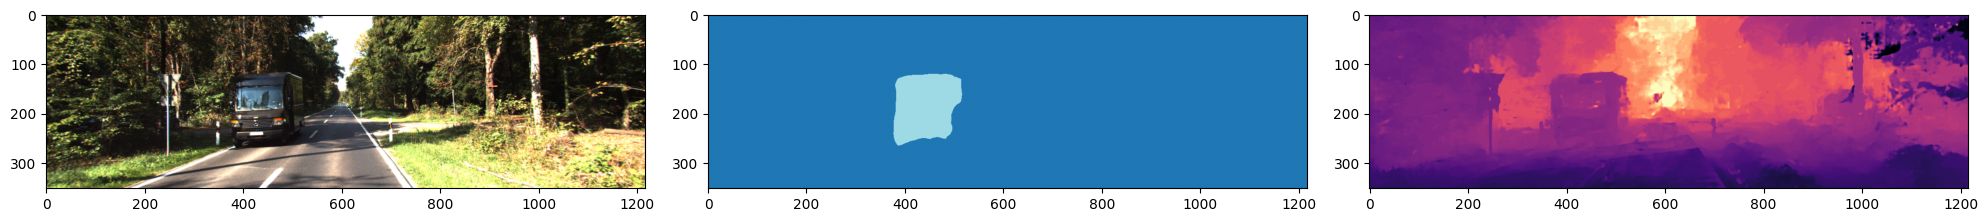

In [56]:
import random
test_idx = random.randint(1, 200)
# test_idx=20
dataset = KittiGTDataset(data_dir)

test_image, test_depth, test_labels = dataset[1]
print(torch.max(test_depth),torch.min(test_depth))

display_three_tensors(test_image, test_labels, test_depth)


# gt_dataset = CScapesGTDataset(data_dir)
# gt_image, gt_disp, gt_seg = gt_dataset[test_idx]
# display_three_tensors(gt_image, gt_seg, gt_disp)

In [57]:
test_image.shape, test_depth.shape, test_labels.shape

(torch.Size([3, 352, 1216]),
 torch.Size([1, 352, 1216]),
 torch.Size([1, 352, 1216]))

In [58]:
torch.max(test_depth), torch.min(test_depth)

(tensor(16.1550), tensor(1.7465))

In [59]:
train_dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [60]:
for batch in train_dataloader:
    images, depths, labels = batch
    print(images.shape, depths.shape, labels.shape)
    break

torch.Size([2, 3, 352, 1216]) torch.Size([2, 1, 352, 1216]) torch.Size([2, 1, 352, 1216])


### Model Classes


In [61]:
def conv_3x3_bn(inp, oup, stride):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )

class PixelShuffleX2(nn.Module):
    def __init__(self, upscale_factor=2):
        super().__init__()
        self.ps = nn.PixelShuffle(upscale_factor)

    def forward(self, x):
        x = self.ps(x)
        return x

class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio):
        super(InvertedResidual, self).__init__()
        assert stride in [1, 2]

        hidden_dim = round(inp * expand_ratio)
        self.identity = stride == 1 and inp == oup

        if expand_ratio == 1:
            self.conv = nn.Sequential(
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                # pw
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # dw
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.ReLU6(inplace=True),
                # pw-linear
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
    
    def forward(self, x):
        if self.identity:
            return x + self.conv(x)
        else:
            return self.conv(x)

In [62]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        pixel = PixelShuffleX2
        bottleneck = InvertedResidual
        self.classes = 21
        self.layer1 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(8,80),
            bottleneck(80, 24, stride=1, expand_ratio=1),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6),
            bottleneck(24, 24, stride=1, expand_ratio=6)
        )
        self.depth_conv_1 = nn.Conv2d(24, 1,kernel_size=1,bias=False)
        self.segm_conv_1 = nn.Conv2d(24, self.classes, kernel_size=1,bias=False)

        self.layer2 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(6,30),
            bottleneck(30, 16, stride=1, expand_ratio=3),
            bottleneck(16, 16, stride=1, expand_ratio=6),
            bottleneck(16, 16, stride=1, expand_ratio=6)
        )
        self.depth_conv_2 = nn.Conv2d(16, 1,kernel_size=1,bias=False)
        self.segm_conv_2 = nn.Conv2d(16, self.classes, kernel_size=1,bias=False)


        self.layer3 = nn.Sequential(
            pixel(2),
            # nn.GroupNorm(4,12),
            bottleneck(12, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_3 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_3 = nn.Conv2d(8, self.classes, kernel_size=1,bias=False)

        self.layer4 = nn.Sequential(
            pixel(4),
            # nn.GroupNorm(1,2),
            bottleneck(2, 8, stride=1, expand_ratio=6),
            bottleneck(8, 8, stride=1, expand_ratio=6)
        )
        self.depth_conv_4 = nn.Conv2d(8, 1,kernel_size=1,bias=False)
        self.segm_conv_4 = nn.Conv2d(8, self.classes, kernel_size=1,bias=False)

    def forward(self, x, skips):
        depth_imgs=[]
        segm_imgs=[]
        # segm_values = torch.arange(-1, 19, dtype=torch.float32)  # Shape: (20,)
        # segm_values = segm_values.view(1, 20, 1, 1)  # Shape: (1, 20, 1, 1)   
        # max_indices = torch.argmax(probs, dim=1, keepdim=True)  # Shape: (B, 1, H, W)
        out1 = self.layer1(x)
        depth_imgs.append(self.depth_conv_1(out1))
        segm_imgs.append(F.softmax(self.segm_conv_1(out1), dim=1))
        # print(out1.shape,skips[4].shape)
        out1 = torch.cat((out1, skips[4]), dim=1)  # Skip connection
        out2 = self.layer2(out1)
        depth_imgs.append(self.depth_conv_2(out2))
        segm_imgs.append(F.softmax(self.segm_conv_2(out2), dim=1))

        out2 = torch.cat((out2, skips[2]), dim=1)  # Skip connection
        out3 = self.layer3(out2)
        depth_imgs.append(self.depth_conv_3(out3))
        segm_imgs.append(F.softmax(self.segm_conv_3(out3), dim=1))

        out3 = torch.cat((out3, skips[1]), dim=1)  # Skip connection
        out4 = self.layer4(out3)
        depth_imgs.append(self.depth_conv_4(out4))
        segm_imgs.append(F.softmax(self.segm_conv_4(out4), dim=1))

        depth_imgs = [img.squeeze(dim=1).to(torch.float32) for img in depth_imgs] # (B, H, W)
        segm_imgs = [img.to(torch.float32) for img in segm_imgs] # (B, C, H, W)
        return depth_imgs, segm_imgs

In [63]:
class MainModel(nn.Module):
    def __init__(self,pretrained_sd,tag = "train"):
        super().__init__()
        self.encoder = mbnetv2() 
        if tag == "train":
            converted_sd = convert_state_dict(pretrained_sd, cfgs)
            self.encoder.load_state_dict(converted_sd)

            for i in self.encoder.parameters():
                i.requires_grad = False

        self.decoder = Decoder()

    def forward(self, x):
        enc_out = self.encoder(x)
        dec_out = self.decoder(enc_out[0], enc_out[1])
        return dec_out

In [64]:
model = MainModel(pretrained_sd,"train")

Initializing weights...


In [65]:
# state = torch.load('saves/cityscapes_v2.pth')
# # state_dict = torch.load('model.pth')
# model.load_state_dict(state)
# # model.eval()

In [66]:
model.to(device)


MainModel(
  (encoder): MobileNetV2(
    (first_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (bottleneck_sequential_blocks): ModuleList(
      (0): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
            (3): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
      )
      (1): Sequential(
        (0): InvertedResidual(
          (conv): Sequential(
            (0): Conv2d(16, 96, kernel_size=(1, 1), str

Testing the Dataset with model


In [67]:
img_tensor, depth_tensor,seg_tensor = dataset[test_idx]
img_tensor = img_tensor.to(device)
img_tensor = img_tensor.unsqueeze(0)
depth_tensor = depth_tensor.unsqueeze(0)
depth_tensor = depth_tensor.to(device)
seg_tensor = seg_tensor.to(device)

In [68]:
print(torch.max(seg_tensor),torch.min(seg_tensor))

tensor(7, device='cuda:0') tensor(0, device='cuda:0')


In [69]:
dec_out, seg_out = model(img_tensor)

In [70]:
for i in dec_out:
    print(i.shape)

torch.Size([1, 22, 76])
torch.Size([1, 44, 152])
torch.Size([1, 88, 304])
torch.Size([1, 352, 1216])


In [71]:
depth_tensor.max()

tensor(16.1550, device='cuda:0')

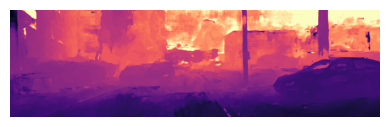

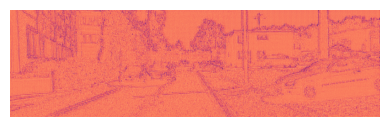

In [72]:
depth_to_display(depth_tensor)  # (1,1,H,W)
depth_to_display(dec_out[3])  # (1,1,H,W)

In [73]:
torch.max(depth_tensor-dec_out[3])

tensor(26.1215, device='cuda:0', grad_fn=<MaxBackward1>)

In [74]:
torch.min(depth_tensor), torch.max(depth_tensor)

(tensor(1.9782, device='cuda:0'), tensor(16.1550, device='cuda:0'))

### LOSS FUNCTIONS


In [75]:
class MultiScaleDepthLoss(nn.Module):
    def __init__(self, m=0.5, M=16, depth_scale=[1,1,1,1]): # depth values normalised to 0-100 hence this choice of m and M
        super(MultiScaleDepthLoss, self).__init__()
        self.m = m
        self.M = M
        self.depth_scale = depth_scale

        # Pre-calculate constants for the G(d) transform for efficiency
        self.log_m = math.log(self.m)
        self.log_M = math.log(self.M)
        self.log_M_minus_log_m = self.log_M - self.log_m

    def _g_transform(self, d):
        # Use sigmoid-based soft clamping instead of hard clamp
        # This preserves gradients everywhere
        eps = 1e-6
        d_normalized = torch.sigmoid((d - self.m) / (self.M - self.m + eps))
        d_soft_clamped = d_normalized * (self.M - self.m) + self.m
        
        log_d = torch.log(d_soft_clamped + eps)  # Add small epsilon to avoid log(0)
        
        return (log_d - self.log_m) * self.M / self.log_M_minus_log_m


    def _berhu_loss(self, diff, c):
        # print("c value:",c)
        # L1 loss for small differences
        l1_loss = diff
        
        # L2-like loss for large differences
        l2_loss = (diff**2 + c**2) / (2 * c)
        
        # Combine using a mask
        mask = diff <= c
        return torch.where(mask, l1_loss, l2_loss)

    def forward(self, pred_depths, gt_depth):

        total_loss = 0.0
        scale = [0.3, 0.5, 0.75, 1.0]
        # Iterate through each predicted depth map scale
        for i,pred_d in enumerate(pred_depths):
            # Get the height and width of the current prediction scale
            _, H_i, W_i = pred_d.shape            
            resized_gt_d = F.interpolate(gt_depth, size=(H_i, W_i), mode='bilinear', align_corners=True)
            resized_gt_d = resized_gt_d.squeeze(dim=1).to(torch.float32)
            
            # Apply the G-transform to both prediction and resized ground truth
            pred_g = self._g_transform(pred_d)
            gt_g = self._g_transform(resized_gt_d)

            # Calculate the absolute difference in the transformed space
            diff = torch.abs(pred_g - gt_g)
            
            # Calculate the dynamic threshold 'c' (20% of the max difference in the batch)
            c = 0.2 * torch.max(diff).detach()
            
            # Calculate the BerHu loss for every pixel
            berhu_pixel_losses = self._berhu_loss(diff, c)
            # Calculate the mean loss for the current scale and add it to the total
            scale_loss = torch.sum(berhu_pixel_losses) / ( H_i * W_i)  # Average over batch and spatial dimensions
            total_loss += scale_loss.mul(self.depth_scale[i])
            
        return total_loss

In [76]:
class MultiScaleSegmLoss(nn.Module):
    def __init__(self, from_logits: bool = False, eps: float = 1e-8,segm_scale=[1,1,1,1]):
        super().__init__()
        self.segm_scale = segm_scale
        self.from_logits = from_logits
        self.eps = eps          # safety term when inputs are probabilities

    def forward(self, segm_preds, segm_gt):
        total_loss = 0.0
        # segm_gt = segm_gt + 1 # converts -1 - 18 to 0-19
        
        if len(segm_gt.shape) == 3:
            segm_gt = segm_gt.unsqueeze(0) #C,H,W -> B,C,H,W

        for i,pred in enumerate(segm_preds):
            B, _, H, W = pred.shape
            # print(pred.shape)
            # resize ground-truth to current scale with nearest-neighbour
            tgt = F.interpolate(segm_gt.float(),
                                size=(H, W),
                                mode="nearest").squeeze(1).long()


            # Convert targets to one-hot encoding: (B, H, W) -> (B, C, H, W)
            # print(tgt.shape)
            targets_one_hot = F.one_hot(tgt, num_classes=21).permute(0, 3, 1, 2).float()
            # print(targets_one_hot.shape)
            # Add small epsilon to avoid log(0)
            # epsilon = 1e-8
            log_predictions = torch.log(pred + self.eps)
            
            # Implement the exact formula from equation (5)
            # Σ(c=1 to C) s^c_{x,y} * log(ŝ^c_{x,y}) for each pixel (x,y)
            pixel_losses = torch.sum(targets_one_hot * log_predictions, dim=1)  # (B, H, W)

            # Sum over all pixels and normalize by image size: 1/(Wi*Hi) * Σ(x,y)
            stage_loss = -torch.sum(pixel_losses) / (W * H * B)
            
            total_loss += stage_loss.mul(self.segm_scale[i])

        return total_loss


In [77]:
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11, data_range=1.0, size_average=True):
        super(SSIMLoss, self).__init__()
        self.window_size = window_size
        self.data_range = data_range
        self.size_average = size_average
        
        # Create Gaussian window (1, 1, window_size, window_size)
        self.window = self._create_window(window_size)
        
    def _gaussian(self, window_size, sigma=1.5):
        gauss = torch.Tensor([
            math.exp(-(x - window_size//2)**2 / (2*sigma**2)) 
            for x in range(window_size)
        ])
        return gauss / gauss.sum()
    
    def _create_window(self, window_size):
        _1D_window = self._gaussian(window_size, 1.5).unsqueeze(1)
        _2D_window = _1D_window.mm(_1D_window.t()).float()
        window = _2D_window.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 11, 11)
        return window
    
    def forward(self, pred, target):
        pred = pred[-1]
        # Add channel dimension: (B, H, W) -> (B, 1, H, W)
        if pred.dim() == 3:
            pred = pred.unsqueeze(1)
            # target = target.unsqueeze(1)
        
        # batch_size = pred.size(0)
        
        # Ensure window is on same device
        if self.window.device != pred.device:
            self.window = self.window.to(pred.device)
        
        # Use the single-channel window
        window = self.window
        
        # Compute local means
        mu1 = F.conv2d(pred, window, padding=self.window_size//2)
        mu2 = F.conv2d(target, window, padding=self.window_size//2)
        
        mu1_sq = mu1.pow(2)
        mu2_sq = mu2.pow(2)
        mu1_mu2 = mu1 * mu2
        
        # Compute local variances and covariance
        sigma1_sq = F.conv2d(pred * pred, window, padding=self.window_size//2) - mu1_sq
        sigma2_sq = F.conv2d(target * target, window, padding=self.window_size//2) - mu2_sq
        sigma12 = F.conv2d(pred * target, window, padding=self.window_size//2) - mu1_mu2
        
        # SSIM constants
        C1 = (0.01 * self.data_range) ** 2
        C2 = (0.03 * self.data_range) ** 2
        
        # SSIM formula
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Average over spatial dimensions, optionally over batch
        if self.size_average:
            return 1 - ssim_map.mean()  # Convert to loss
        else:
            return 1 - ssim_map.mean(dim=[1, 2, 3])  # Per-batch losses

In [78]:
def edge_aware_smoothness_loss( pred, depth):    
    # Compute gradients
    pred = pred[-1]
    depth = depth.squeeze(dim=1).to(torch.float32)
    depth_grad_x = torch.abs(depth[:, :, :-1] - depth[:, :, 1:])
    depth_grad_y = torch.abs(depth[:, :-1, :] - depth[:, 1:, :])

    image_grad_x = torch.abs(pred[:,  :, :-1] - pred[:,  :, 1:])
    image_grad_y = torch.abs(pred[:,  :-1, :] - pred[:, 1:, :])

    # Edge-aware weighting
    smooth_x = depth_grad_x * torch.exp(-image_grad_x)
    smooth_y = depth_grad_y * torch.exp(-image_grad_y)
    # loss = torch.sum(torch.abs(depth_grad_x - image_grad_x)) + torch.sum(torch.abs(depth_grad_y - image_grad_y))
    # loss /= (pred.size(1) * pred.size(2))

    return torch.mean(smooth_x) + torch.mean(smooth_y)


In [79]:
test_dept_loss = MultiScaleDepthLoss()
test_segm_loss = MultiScaleSegmLoss()
ssim_loss = SSIMLoss()
print("Segm shapes:", seg_out[0].shape, seg_tensor.shape)
print("Depth shapes:", dec_out[0].shape, depth_tensor.shape)
print("Depth Loss:", test_dept_loss(dec_out, depth_tensor).item())
print("Segmentation Loss:", test_segm_loss(seg_out, seg_tensor).item())
print("SSIM Loss:", ssim_loss(dec_out, depth_tensor).item())
# print()
print("Edge-aware smoothness Loss:", edge_aware_smoothness_loss(dec_out, depth_tensor).item())

Segm shapes: torch.Size([1, 21, 22, 76]) torch.Size([1, 352, 1216])
Depth shapes: torch.Size([1, 22, 76]) torch.Size([1, 1, 352, 1216])
Depth Loss: 5.957943916320801
Segmentation Loss: 13.899024963378906
SSIM Loss: 0.9995021224021912
Edge-aware smoothness Loss: 0.060178499668836594


## Dataset Prep


In [80]:
import glob
from datetime import datetime

def get_next_log_number(log_dir='logs'):
    """Find the next available log file number"""
    os.makedirs(log_dir, exist_ok=True)
    existing_logs = glob.glob(os.path.join(log_dir, 'training_log_*.txt'))
    
    if not existing_logs:
        return 1
    
    numbers = []
    for log_file in existing_logs:
        try:
            num = int(log_file.split('_')[-1].split('.')[0])
            numbers.append(num)
        except ValueError:
            continue
    
    return max(numbers) + 1 if numbers else 1


def train_multi_scale_depth_model(model, dataloader, num_epochs=100, lr=1e-2, 
                                   depth_scale=[1,1,1,1], segm_scale=[1,1,1,1], 
                                   log_dir='logs'):
    # Setup logging
    log_num = get_next_log_number(log_dir)
    log_file = os.path.join(log_dir, f'training_log_{log_num}.txt')
    
    def log_message(message, print_msg=True):
        """Write message to both console and log file"""
        if print_msg:
            print(message)
        with open(log_file, 'a') as f:
            f.write(message + '\n')
    
    # Log training configuration
    log_message(f"{'='*60}")
    log_message(f"Training Log #{log_num}")
    log_message(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    log_message(f"{'='*60}")
    log_message(f"Configuration:")
    log_message(f"  Epochs: {num_epochs}")
    log_message(f"  Learning Rate: {lr}")
    log_message(f"  Depth Scale: {depth_scale}")
    log_message(f"  Segmentation Scale: {segm_scale}")
    log_message(f"  Device: {device}")
    log_message(f"  Batch Size: {dataloader.batch_size}")
    log_message(f"  Dataset Size: {len(dataloader.dataset)}")
    log_message(f"{'='*60}\n")
    
    # Initialize loss functions and optimizer
    depth_loss = MultiScaleDepthLoss(depth_scale=depth_scale)
    segm_loss = MultiScaleSegmLoss(segm_scale=segm_scale)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
    
    model.train()
    Loss_history = []
    
    try:
        for epoch in range(num_epochs):
            epoch_loss = 0.0
            
            for batch_idx, (color_input, depth_gt, labels) in enumerate(dataloader):
                
                if batch_idx > 1000:
                    break
                
                # Move data to device
                color_input = color_input.to(device, non_blocking=True).float()
                depth_gt = depth_gt.to(device, non_blocking=True).float()
                labels = labels.to(device, non_blocking=True).int()
                
                optimizer.zero_grad()
                
                # Forward pass
                depth_predictions, segprob_predictions = model(color_input)
                
                # Calculate loss
                total_loss = (depth_loss(depth_predictions, depth_gt) + 
                             segm_loss(segprob_predictions, labels) + 
                             5 * edge_aware_smoothness_loss(depth_predictions, depth_gt))
                
                # Backward pass
                total_loss.backward()
                optimizer.step()
                
                epoch_loss += total_loss.item()
                
                # Log progress every 50 batches
                if batch_idx % 50 == 0:
                    scheduler.step()
                    msg = (f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx}, '
                           f'Loss: {total_loss.item():.4f}')
                    log_message(msg)
                    Loss_history.append(total_loss.item())
            
            # End of epoch
            scheduler.step()
            avg_loss = epoch_loss / len(dataloader)
            msg = f'Epoch {epoch+1} completed. Average Loss: {avg_loss:.4f}'
            log_message(msg)
            log_message('')  # Empty line for readability
    
    except KeyboardInterrupt:
        log_message("\n" + "="*60)
        log_message("Training interrupted by user!")
        log_message(f"Completed {epoch+1} epochs before interruption")
        log_message(f"Loss history saved with {len(Loss_history)} entries")
        log_message("="*60)
        print("\nTraining interrupted. Loss history has been saved.")
    
    except Exception as e:
        log_message("\n" + "="*60)
        log_message(f"Training failed with error: {str(e)}")
        log_message("="*60)
        raise
    
    finally:
        # Always log completion
        log_message("\n" + "="*60)
        log_message(f"Training session ended: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        log_message(f"Total loss entries recorded: {len(Loss_history)}")
        log_message("="*60)
    
    return Loss_history


In [81]:
depth_scale = [0.5, 0.7, 0.9, 1.0] 
segm_scale = [0.0, 0.0, 0.0, 0.0] 

In [ ]:
Loss_history = train_multi_scale_depth_model(model, train_dataloader, num_epochs=25, lr=3e-3, depth_scale=depth_scale, segm_scale=segm_scale)

Training Log #1
Started: 2026-01-09 01:48:22
Configuration:
  Epochs: 25
  Learning Rate: 0.003
  Depth Scale: [0.5, 0.7, 0.9, 1.0]
  Segmentation Scale: [0.0, 0.0, 0.0, 0.0]
  Device: cuda
  Batch Size: 2
  Dataset Size: 400

Epoch 1/25, Batch 0, Loss: 8.9239
Epoch 1/25, Batch 50, Loss: 9.5972
Epoch 1/25, Batch 100, Loss: 5.6467
Epoch 1/25, Batch 150, Loss: 2.1921
Epoch 1 completed. Average Loss: 5.8105

Epoch 2/25, Batch 0, Loss: 1.3666
Epoch 2/25, Batch 50, Loss: 1.5392
Epoch 2/25, Batch 100, Loss: 1.3762
Epoch 2/25, Batch 150, Loss: 0.9151
Epoch 2 completed. Average Loss: 1.4310

Epoch 3/25, Batch 0, Loss: 1.2788
Epoch 3/25, Batch 50, Loss: 1.1084
Epoch 3/25, Batch 100, Loss: 1.1390
Epoch 3/25, Batch 150, Loss: 1.2387
Epoch 3 completed. Average Loss: 1.3021

Epoch 4/25, Batch 0, Loss: 1.2061
Epoch 4/25, Batch 50, Loss: 1.1829
Epoch 4/25, Batch 100, Loss: 1.1650
Epoch 4/25, Batch 150, Loss: 1.1690
Epoch 4 completed. Average Loss: 1.2691

Epoch 5/25, Batch 0, Loss: 1.1262
Epoch 5/25,

# Results and Analysis

**TO-DO's**
- Make the code modular so that it fits with any dataset.
- Prepare Validation Loss and Error evaluation part with val data.
- Check with higher res images
- Organise and mention tensor shapes at each point to prevent confusion later on. Try to keep same shapes at same levels.

In [ ]:
img_tensor, depth_tensor,seg_tensor = dataset[90]
img_tensor = img_tensor.to(device)
img_tensor = img_tensor.unsqueeze(0)
depth_tensor = depth_tensor.unsqueeze(0)
depth_tensor = depth_tensor.to(device)
seg_tensor = seg_tensor.unsqueeze(0)
seg_tensor = seg_tensor.to(device)


In [ ]:
img_tensor.shape, depth_tensor.shape, seg_tensor.shape # all in BCHW with B = 1

In [ ]:
output,segm = model(img_tensor)
output[0].shape, segm[0].shape


In [ ]:
# torch.max(segm[-1]),torch.min(segm[-1])

In [ ]:
segmented_image = torch.argmax(segm[3], dim=1, keepdim=True) -1 # convert back to -1 - 18
# print()
print(torch.max(segm[3][0][19][:][:]))
print(torch.min(segmented_image), torch.max(segmented_image))
print(torch.min(seg_tensor),torch.max(seg_tensor))
# print(segmented_image[-1]-seg_tensor)
# print()
display_three_tensors(img_tensor.squeeze(0), segmented_image.squeeze(0), output[3])
display_three_tensors(img_tensor.squeeze(0), seg_tensor.squeeze(0), depth_tensor.squeeze(0))


In [ ]:
torch.save(model.state_dict(), 'saves/kitti_v1.pth')

In [ ]:
#LOSS Curve
plt.figure(figsize=(12,5))
plt.plot(Loss_history)
plt.xlabel('Iteration (x50)')
plt.ylabel('Loss')  
plt.title('Training Loss Curve')

In [ ]:
# find no. of occurrences of each class
for i in range(-1,20):
    if torch.sum(seg_tensor == i).item() > 0:
        print("GT Segm",i, torch.sum(seg_tensor == i))
    if torch.sum(segmented_image == i).item() > 0:
        print("Pred Segm",i, torch.sum(segmented_image == i))

In [ ]:
torch.mean(output[3]-depth_tensor)

In [ ]:
mbnetv2 = mbnetv2()

In [ ]:
encoder_params = sum(p.numel() for p in mbnetv2.parameters())
print(f'Encoder parameters: {encoder_params}')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total number of parameters: {total_params}')
print(f'Total decoder parameters: {total_params - encoder_params}')


In [ ]:
def rmse(pred, target):
    pred = pred[-1]
    return torch.sqrt(torch.mean((pred - target) ** 2))

In [ ]:
rmse(output, depth_tensor)

In [ ]:
print(torch.max(output[3]).item(),
torch.max(depth_tensor).item(),
torch.min(torch.abs(output[3]-depth_tensor)).item())

In [ ]:
# torch.save(model.state_dict(), '../saves/v2.pth')


In [ ]:
def smooth_depth_prediction(depth_tensor, kernel_size=5):
    """Apply Gaussian smoothing to reduce noise"""
    import torch.nn.functional as F
    
    # Create Gaussian kernel
    sigma = kernel_size / 3.0
    kernel_1d = torch.exp(-0.5 * (torch.arange(kernel_size) - kernel_size//2)**2 / sigma**2)
    kernel_1d = kernel_1d / kernel_1d.sum()
    
    # 2D separable Gaussian
    kernel_2d = kernel_1d[:, None] * kernel_1d[None, :]
    kernel_2d = kernel_2d.unsqueeze(0).unsqueeze(0).to(depth_tensor.device)
    
    # Apply smoothing
    smooth_depth = F.conv2d(depth_tensor, kernel_2d, padding=kernel_size//2)
    return smooth_depth

# Use during inference
with torch.no_grad():
    raw_pred = model(img_tensor)
    smooth_pred = smooth_depth_prediction(raw_pred[-1])


In [ ]:
depth_to_display(smooth_pred)